In [1]:
import numpy as np 
import pandas as pd

data = pd.read_csv('C:/Users/24651/Desktop/fer2013.csv')
num_of_instances = len(data) #获取数据集的数量
print("数据集的数量为：",num_of_instances)

pixels = data['pixels']
emotions = data['emotion']
usages = data['Usage']

数据集的数量为： 35887


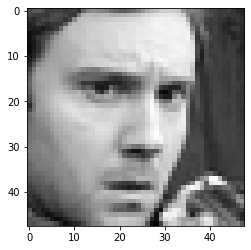

In [28]:
import cv2
img0 = list(map(eval,pixels[0].split(' ')))
np_img0 = np.asarray(img0)
img0 = np_img0.reshape(48,48)
import matplotlib.pyplot as plt
plt.imshow(img0, cmap="gray")


In [3]:
emotions_Str=['anger','disgust','fear','happy','neutral','sad','surprised']

In [5]:
from keras.utils import to_categorical
from PIL import Image
import os

num_classes = 7   #表情的类别数目
x_train,y_train,x_val,y_val,x_test,y_test = [],[],[],[],[],[]
from tqdm import tqdm
for i in tqdm(range(num_of_instances)):
    usages_name = usages[i]
    emotions_Str_Nmae = emotions_Str[emotions[i]]
    one_hot_label = to_categorical(emotions[i],num_classes)
    img = list(map(eval,pixels[i].split(' ')))
    np_img = np.asarray(img)
    img = np_img.reshape(48,48)
    if usages[i] == 'Training':
        x_train.append(img)
        y_train.append(one_hot_label)
    elif usages[i] == 'PrivateTest':
        x_val.append(img)
        y_val.append(one_hot_label)
    else:
        x_test.append(img)
        y_test.append(one_hot_label)
    subfolder = os.path.join('C:\\Users\\24651\\Desktop\\',usages_name,emotions_Str_Nmae)
    if not os.path.exists(subfolder):
        os.makedirs(subfolder)
    im = Image.fromarray(img).convert('L')
    im.save(os.path.join(subfolder , (str(i)+'.jpg') ))

100%|████████████████████████████████████████████████████████████████████████████| 35887/35887 [06:10<00:00, 96.91it/s]


In [6]:
len(x_train)

28709

In [7]:
x_train = np.array(x_train)
y_train = np.array(y_train)
x_train = x_train.reshape(-1,48,48,1)
x_test = np.array(x_test)
y_test = np.array(y_test)
x_test = x_test.reshape(-1,48,48,1)
x_val = np.array(x_val).reshape(-1,48,48,1)
y_val = np.array(y_val)

In [8]:
len(x_train),len(x_test),len(x_val)

(28709, 3589, 3589)

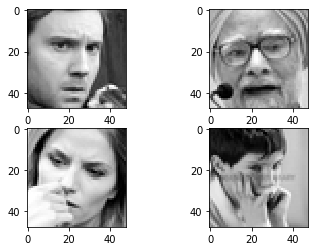

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline

for i in range(4): 
    plt.subplot(221+i)
    plt.gray()
    plt.imshow(x_train[i].reshape([48,48]))

In [10]:
x_train.shape[1:]
x_val.shape

(3589, 48, 48, 1)

In [2]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Activation, Dropout, Flatten, Dense
from keras.optimizers import Adam
from keras.preprocessing.image import ImageDataGenerator

batch_size = 128
epochs = 20

model = Sequential()

# 第一层卷积层
model.add(Conv2D(input_shape=(48, 48, 1), filters=32, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

# 第二层卷积层
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

# 第三层卷积层
model.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

model.add(Flatten())

# 全连接层
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(7, activation='softmax'))


In [9]:
%matplotlib inline
from IPython.display import SVG
from keras.utils.vis_utils import model_to_dot

SVG(model_to_dot(model,show_shapes=True,dpi=60).create(prog='dot',format='svg'))

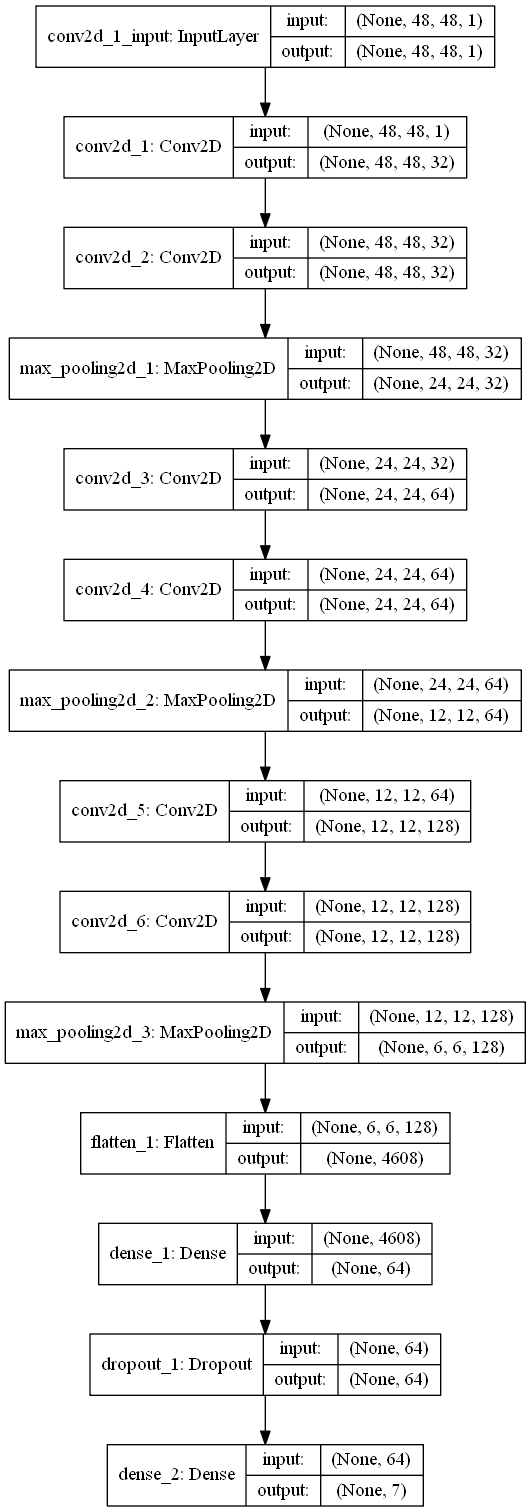

In [13]:
from keras.utils import plot_model
plot_model(model,show_shapes= True, to_file='model.png')

In [14]:
#进行训练
model.compile(loss = 'categorical_crossentropy',optimizer = Adam(),metrics=['accuracy'])
history = model.fit(x_train,y_train,batch_size=batch_size,epochs=epochs,validation_data=(x_val,y_val))
 
test_score = model.evaluate(x_test, y_test)

Train on 28709 samples, validate on 3589 samples
Epoch 1/20
28709/28709 [==============================] - 179s 6ms/step - loss: 2.5097 - accuracy: 0.1582 - val_loss: 1.8669 - val_accuracy: 0.2020
Epoch 2/20
28709/28709 [==============================] - 182s 6ms/step - loss: 1.8569 - accuracy: 0.2387 - val_loss: 1.8659 - val_accuracy: 0.1725
Epoch 3/20
28709/28709 [==============================] - 180s 6ms/step - loss: 1.8243 - accuracy: 0.2551 - val_loss: 1.7495 - val_accuracy: 0.3101
Epoch 4/20
28709/28709 [==============================] - 180s 6ms/step - loss: 1.7931 - accuracy: 0.2635 - val_loss: 1.7434 - val_accuracy: 0.2953
Epoch 5/20
28709/28709 [==============================] - 183s 6ms/step - loss: 1.7677 - accuracy: 0.2667 - val_loss: 1.7208 - val_accuracy: 0.3135
Epoch 6/20
28709/28709 [==============================] - 180s 6ms/step - loss: 1.7508 - accuracy: 0.2728 - val_loss: 1.6813 - val_accuracy: 0.3193
Epoch 7/20
28709/28709 [==============================] - 182s 

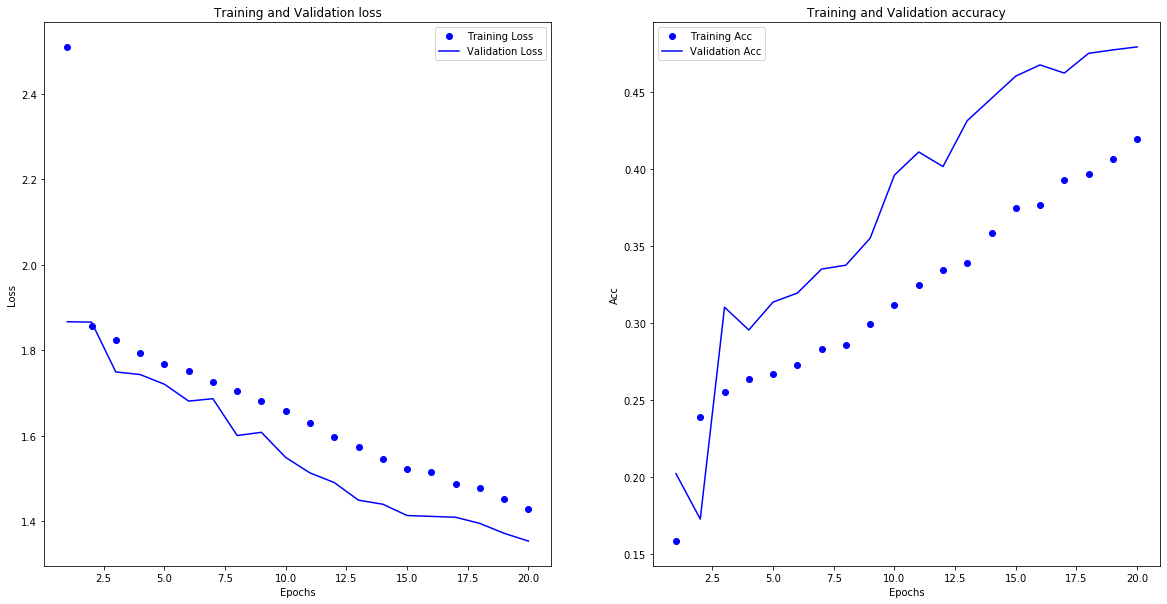

In [25]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs2 = range(1,epochs+1)
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(121)
ax.plot(epochs2,loss,'bo',label = 'Training Loss')
ax.plot(epochs2,val_loss,'b',label='Validation Loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
ax2 = fig.add_subplot(122)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
ax2.plot(epochs2,acc,'bo',label = 'Training Acc')
ax2.plot(epochs2,val_acc,'b',label='Validation Acc')
plt.title('Training and Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Acc')
plt.legend()
plt.savefig('C:/Users/24651/Desktop/result.png')
plt.show()


In [ ]:
np.argmin(history.history['val_loss'])

In [26]:
test_score

[1.3474807781773246, 0.4789634943008423]

In [ ]:
np.argmax(history.history['val_accuracy'])